# Cinematica Direta e Inversa do Robo Snake

Este documento segue o padrao do material fornecido pelo professor, organizando o desenvolvimento em etapas:

1. matriz de transformacao homogenea generica;
2. tabela de parametros DH;
3. cinematica direta;
4. validacao com a prancha tecnica;
5. cinematica inversa por Jacobiano amortecido.

O robo snake considerado possui **3 modulos**, com **3 juntas por modulo**, totalizando **9 juntas rotativas**.


## Prancha tecnica de referencia

A imagem abaixo contem as cotas usadas no modelo.

![Prancha tecnica de referencia](imagens/prancha_tecnica_referencia.png)

Medidas principais utilizadas:

- distancia centro-centro entre juntas do suporte: `15,17 mm`;
- deslocamento horizontal da pose de referencia: `62,39 mm`;
- deslocamento vertical centro-centro da pose de referencia: `115,51 mm`.

Neste documento, a origem `(0, 0)` esta no ponto inferior da montagem. Assim, o ponto superior da pose de referencia fica em:

`[-62,39 mm, 115,51 mm]`


## Importando as bibliotecas

Sao importadas bibliotecas para manipulacao simbolica, calculo numerico, exibicao de matrizes e geracao dos graficos.


In [17]:
from sympy import *
from IPython.display import display, Markdown
from IPython.core.interactiveshell import InteractiveShell
import matplotlib.pyplot as plt
import numpy as np

InteractiveShell.ast_node_interactivity = "all"
init_printing(use_latex=True)


## 1. Matriz de Transformacao Homogenea Generica obtida a partir dos Rotacionais e Translacionais

Seguindo a convencao de Denavit-Hartenberg, a matriz homogenea de cada elo pode ser escrita como:

`H = RotZ(theta) * TranslZ(d) * TranslX(a) * RotX(alpha)`

onde:

- `theta`: angulo da junta;
- `d`: deslocamento ao longo de `z`;
- `a`: comprimento do elo ao longo de `x`;
- `alpha`: torcao entre eixos consecutivos.


In [18]:
def componentes_matriz(theta, d, a, alpha):
    RotZ = Matrix([
        [cos(theta), -sin(theta), 0, 0],
        [sin(theta),  cos(theta), 0, 0],
        [0,           0,          1, 0],
        [0,           0,          0, 1],
    ])

    TranslZ = Matrix([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 1, d],
        [0, 0, 0, 1],
    ])

    TranslX = Matrix([
        [1, 0, 0, a],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])

    RotX = Matrix([
        [1, 0,           0,          0],
        [0, cos(alpha), -sin(alpha), 0],
        [0, sin(alpha),  cos(alpha), 0],
        [0, 0,           0,          1],
    ])

    return RotZ, TranslZ, TranslX, RotX


def matriz_dh(theta, d, a, alpha):
    RotZ, TranslZ, TranslX, RotX = componentes_matriz(theta, d, a, alpha)
    return simplify(RotZ * TranslZ * TranslX * RotX)


### 1.1 Componentes da matriz

Inicialmente, as quatro matrizes sao apresentadas separadamente.


**RotZ(theta)**

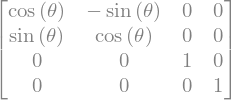

**TranslZ(d)**

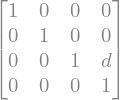

**TranslX(a)**

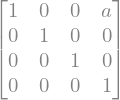

**RotX(alpha)**

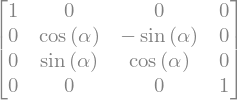

In [19]:
theta, d, a, alpha = symbols("theta d a alpha")
RotZ, TranslZ, TranslX, RotX = componentes_matriz(theta, d, a, alpha)

display(Markdown("**RotZ(theta)**"))
display(RotZ)

display(Markdown("**TranslZ(d)**"))
display(TranslZ)

display(Markdown("**TranslX(a)**"))
display(TranslX)

display(Markdown("**RotX(alpha)**"))
display(RotX)


### 1.2 Matriz homogenea generica

Multiplicando as componentes, obtem-se a matriz DH generica.


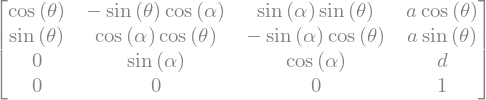

In [20]:
H_generica = matriz_dh(theta, d, a, alpha)
display(H_generica)


## 2. Definicao do robo snake

O robo e formado por 3 modulos com 3 juntas cada.

A distancia centro-centro entre juntas foi obtida da prancha tecnica:

`L = 15,17 mm = 0,01517 m`


In [21]:
n_modulos = 3
juntas_por_modulo = 3
n_juntas = n_modulos * juntas_por_modulo

L_mm = 15.17
L = L_mm / 1000

alvo_desenho_mm = np.array([-62.39, 115.51])
alvo_desenho = alvo_desenho_mm / 1000

print("Modulos:", n_modulos)
print("Juntas por modulo:", juntas_por_modulo)
print("Total de juntas:", n_juntas)
print("Distancia centro-centro:", L_mm, "mm")
print("Alvo da pose de referencia:", alvo_desenho_mm, "mm")


Modulos: 3
Juntas por modulo: 3
Total de juntas: 9
Distancia centro-centro: 15.17 mm
Alvo da pose de referencia: [-62.39 115.51] mm


## 3. Tabela de Parametros DH

Como primeira aproximacao, o robo snake e tratado como um manipulador planar.

Para cada junta:

- `theta_i`: variavel da junta;
- `d_i = 0`;
- `a_i = L`;
- `alpha_i = 0`.

Assim, cada elo possui uma rotacao em torno de `z` e uma translacao de comprimento `L` no eixo `x` local.


In [22]:
theta_symbols = symbols(f"theta1:{n_juntas + 1}")

tabela_dh = []
for i in range(n_juntas):
    tabela_dh.append({
        "elo": i + 1,
        "theta": theta_symbols[i],
        "d": 0,
        "a": L,
        "alpha": 0,
    })

for linha in tabela_dh:
    print(
        f"Elo {linha['elo']}: "
        f"theta={linha['theta']}, d={linha['d']}, a={linha['a']}, alpha={linha['alpha']}"
    )


Elo 1: theta=theta1, d=0, a=0.01517, alpha=0
Elo 2: theta=theta2, d=0, a=0.01517, alpha=0
Elo 3: theta=theta3, d=0, a=0.01517, alpha=0
Elo 4: theta=theta4, d=0, a=0.01517, alpha=0
Elo 5: theta=theta5, d=0, a=0.01517, alpha=0
Elo 6: theta=theta6, d=0, a=0.01517, alpha=0
Elo 7: theta=theta7, d=0, a=0.01517, alpha=0
Elo 8: theta=theta8, d=0, a=0.01517, alpha=0
Elo 9: theta=theta9, d=0, a=0.01517, alpha=0


## 4. Matriz de Transformacao Homogenea de cada elo

Substituindo `d = 0`, `a = L` e `alpha = 0`, obtem-se a matriz usada em cada junta do robo.


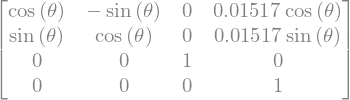

In [23]:
H_elo = matriz_dh(theta, 0, L, 0)
display(H_elo)


## 5. Cinematica Direta

A cinematica direta calcula a posicao da ponta a partir dos angulos das juntas.

A transformacao total e dada por:

`T_total = H1 * H2 * H3 * ... * H9`

A posicao da ponta e obtida na ultima coluna da matriz homogenea final.


In [24]:
def matriz_dh_numerica(theta, d, a, alpha):
    return np.array([
        [np.cos(theta), -np.sin(theta) * np.cos(alpha),  np.sin(theta) * np.sin(alpha), a * np.cos(theta)],
        [np.sin(theta),  np.cos(theta) * np.cos(alpha), -np.cos(theta) * np.sin(alpha), a * np.sin(theta)],
        [0,              np.sin(alpha),                  np.cos(alpha),                 d],
        [0,              0,                              0,                             1],
    ], dtype=float)


def cinematica_direta(q_graus):
    q = np.deg2rad(q_graus)
    T_total = np.eye(4)
    posicoes = [T_total[:2, 3].copy()]

    for theta_i in q:
        H_i = matriz_dh_numerica(theta_i, 0, L, 0)
        T_total = T_total @ H_i
        posicoes.append(T_total[:2, 3].copy())

    return T_total, np.array(posicoes)


### 5.1 Configuracao de referencia

A configuracao abaixo foi escolhida para reproduzir a pose da prancha tecnica, usando a origem no ponto inferior da montagem.


**Matriz final da base ate a ponta**

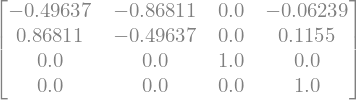

Angulos de referencia [graus]:
[ 94.61  17.87  19.1   10.48  -3.75 -15.83 -17.68  -5.46  20.42]
Ponta calculada [mm]: [-62.39 115.5 ]
Alvo do desenho [mm]: [-62.39 115.51]
Erro [mm]: [-0.003  -0.0056]
Erro total [mm]: 0.0064


In [25]:
q_referencia_graus = np.array([
     94.61,  17.87,  19.10,
     10.48,  -3.75, -15.83,
    -17.68,  -5.46,  20.42,
])

T_direta, pos_direta = cinematica_direta(q_referencia_graus)
ponta_direta_mm = pos_direta[-1] * 1000
erro_direta_mm = ponta_direta_mm - alvo_desenho_mm

display(Markdown("**Matriz final da base ate a ponta**"))
display(Matrix(np.round(T_direta, 5)))

print("Angulos de referencia [graus]:")
print(q_referencia_graus)
print("Ponta calculada [mm]:", np.round(ponta_direta_mm, 2))
print("Alvo do desenho [mm]:", alvo_desenho_mm)
print("Erro [mm]:", np.round(erro_direta_mm, 4))
print("Erro total [mm]:", round(np.linalg.norm(erro_direta_mm), 4))


### 5.2 Validacao pela forma planar

Como o robo e planar, tambem e possivel verificar o resultado usando a soma dos angulos acumulados:

`phi_i = theta_1 + theta_2 + ... + theta_i`

`x = L * soma(cos(phi_i))`

`y = L * soma(sin(phi_i))`


In [26]:
phi = np.cumsum(np.deg2rad(q_referencia_graus))
x_planar = L * np.sum(np.cos(phi))
y_planar = L * np.sum(np.sin(phi))

print("Resultado pela soma seno/cosseno [mm]:", np.round(np.array([x_planar, y_planar]) * 1000, 2))
print("Resultado pela matriz homogenea [mm]:", np.round(ponta_direta_mm, 2))


Resultado pela soma seno/cosseno [mm]: [-62.39 115.5 ]
Resultado pela matriz homogenea [mm]: [-62.39 115.5 ]


### 5.3 Desenho da pose pela cinematica direta

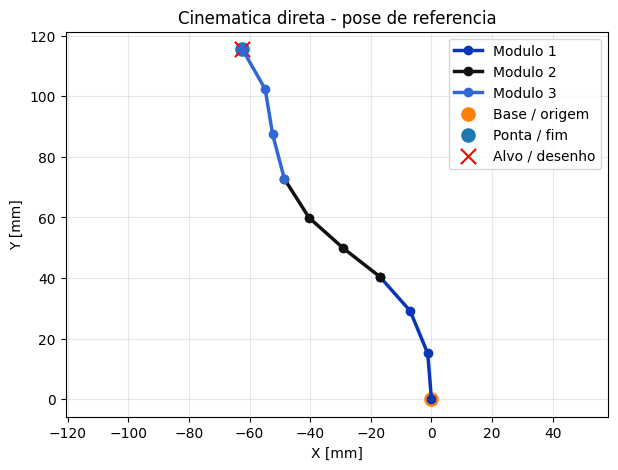

In [27]:
def desenhar_robo(posicoes, alvo_mm=None, titulo="Robo snake"):
    cores = ["#0b36b8", "#111111", "#3267d6"]
    fig, ax = plt.subplots(figsize=(7, 5))

    for modulo in range(n_modulos):
        inicio = modulo * juntas_por_modulo
        fim = inicio + juntas_por_modulo
        trecho = posicoes[inicio:fim + 1]
        ax.plot(
            trecho[:, 0] * 1000,
            trecho[:, 1] * 1000,
            "-o",
            linewidth=2.5,
            color=cores[modulo],
            label=f"Modulo {modulo + 1}",
        )

    ax.scatter([0], [0], s=90, color="#ff7f0e", label="Base / origem")
    ax.scatter([posicoes[-1, 0] * 1000], [posicoes[-1, 1] * 1000], s=90, color="#1f77b4", label="Ponta / fim")
    if alvo_mm is not None:
        ax.scatter([alvo_mm[0]], [alvo_mm[1]], marker="x", s=120, color="red", label="Alvo / desenho")

    ax.set_title(titulo)
    ax.set_xlabel("X [mm]")
    ax.set_ylabel("Y [mm]")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

desenhar_robo(pos_direta, alvo_desenho_mm, "Cinematica direta - pose de referencia")


## 6. Cinematica Inversa

A cinematica inversa busca os angulos das juntas a partir de uma posicao desejada da ponta.

Neste caso, o alvo e:

`p_d = [-62,39 mm, 115,51 mm]`

Como o robo tem 9 juntas para posicionar a ponta no plano, existem varias solucoes possiveis. Por isso, usa-se um metodo numerico baseado no Jacobiano.


## Imagens de apoio da cinematica inversa

As imagens abaixo mostram visualmente as etapas principais da cinematica inversa.

**1. Alvo definido para a ponta**

![Alvo da cinematica inversa](imagens/cinematica_inversa_alvo.png)

**2. Pose inicial antes do metodo iterativo**

![Pose inicial da cinematica inversa](imagens/cinematica_inversa_pose_inicial.png)

**3. Solucao final encontrada**

![Solucao da cinematica inversa](imagens/cinematica_inversa_solucao.png)

**4. Convergencia do erro**

![Convergencia do erro da cinematica inversa](imagens/cinematica_inversa_convergencia.png)


### 6.1 Jacobiano da ponta

Para o caso planar, o Jacobiano relaciona pequenas variacoes nos angulos com pequenas variacoes na posicao da ponta:

`delta_p = J * delta_theta`

Como a ponta possui duas coordenadas e o robo possui nove juntas, o Jacobiano tem dimensao `2 x 9`.


In [28]:
def jacobiano_ponta(q_rad):
    phi = np.cumsum(q_rad)
    J = np.zeros((2, len(q_rad)))

    for j in range(len(q_rad)):
        J[0, j] = -L * np.sum(np.sin(phi[j:]))
        J[1, j] =  L * np.sum(np.cos(phi[j:]))

    return J


### 6.2 Metodo numerico por Jacobiano amortecido

A correcao dos angulos e calculada por:

`delta_theta = J^T * (J * J^T + lambda^2 * I)^-1 * erro`

O termo `lambda` e o amortecimento, usado para deixar o metodo mais estavel.


In [29]:
def cinematica_inversa(alvo, q_inicial_graus, max_iter=500, tolerancia=1e-5, amortecimento=0.05):
    q = np.deg2rad(q_inicial_graus.astype(float))
    historico_erros = []

    for _ in range(max_iter):
        _, posicoes = cinematica_direta(np.rad2deg(q))
        ponta = posicoes[-1]

        erro = alvo - ponta
        erro_norma = np.linalg.norm(erro)
        historico_erros.append(erro_norma)

        if erro_norma < tolerancia:
            break

        J = jacobiano_ponta(q)
        I = np.eye(2)
        dq = J.T @ np.linalg.solve(J @ J.T + (amortecimento**2) * I, erro)

        passo_maximo = np.deg2rad(5)
        norma_dq = np.linalg.norm(dq)
        if norma_dq > passo_maximo:
            dq = dq * (passo_maximo / norma_dq)

        q = q + dq

    return np.rad2deg(q), historico_erros


### 6.3 Resolucao da cinematica inversa

O chute inicial escolhido e uma configuracao vertical simples. O algoritmo ajusta os angulos ate a ponta se aproximar do alvo.


In [30]:
q_inicial_graus = np.array([
    90, 0, 0,
     0, 0, 0,
     0, 0, 0,
], dtype=float)

q_inversa_graus, erros = cinematica_inversa(alvo_desenho, q_inicial_graus)
T_inversa, pos_inversa = cinematica_direta(q_inversa_graus)
ponta_inversa_mm = pos_inversa[-1] * 1000
erro_inversa_mm = ponta_inversa_mm - alvo_desenho_mm

print("Angulos encontrados pela cinematica inversa [graus]:")
print(np.round(q_inversa_graus, 2))
print("Ponta calculada [mm]:", np.round(ponta_inversa_mm, 2))
print("Alvo [mm]:", alvo_desenho_mm)
print("Erro [mm]:", np.round(erro_inversa_mm, 4))
print("Erro total [mm]:", round(np.linalg.norm(erro_inversa_mm), 4))
print("Iteracoes:", len(erros))


Angulos encontrados pela cinematica inversa [graus]:
[93.13  5.28  6.74  7.48  7.52  6.9   5.7   4.06  2.11]
Ponta calculada [mm]: [-62.4  115.52]
Alvo [mm]: [-62.39 115.51]
Erro [mm]: [-0.0055  0.008 ]
Erro total [mm]: 0.0097
Iteracoes: 33


### 6.4 Desenho da solucao inversa

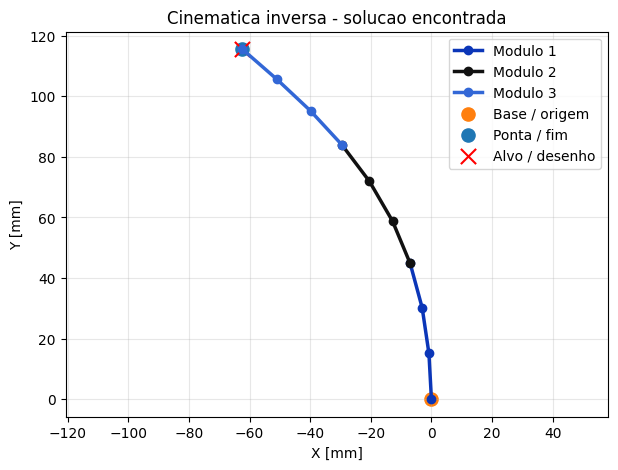

In [31]:
desenhar_robo(pos_inversa, alvo_desenho_mm, "Cinematica inversa - solucao encontrada")


### 6.5 Convergencia do erro

Text(0.5, 1.0, 'Erro da ponta durante a cinematica inversa')

Text(0.5, 0, 'Iteracao')

Text(0, 0.5, 'Erro [mm]')

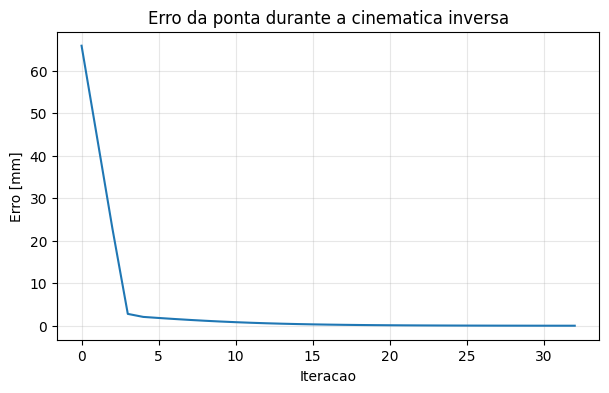

In [32]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.array(erros) * 1000)
ax.set_title("Erro da ponta durante a cinematica inversa")
ax.set_xlabel("Iteracao")
ax.set_ylabel("Erro [mm]")
ax.grid(True, alpha=0.3)
plt.show()


## 7. Conclusao

A cinematica direta foi usada para calcular a posicao da ponta a partir dos angulos das juntas. A pose obtida foi comparada com a prancha tecnica, apresentando erro muito pequeno.

Em seguida, a cinematica inversa foi resolvida numericamente pelo metodo do Jacobiano amortecido. Como o robo possui 9 juntas e a ponta e definida apenas por `(x, y)`, a solucao encontrada nao e unica, mas e valida para levar a ponta ao alvo especificado.
